**ANÁLISIS SERIE TEMPORAL DE GENERACIÓN DEL INVERSOR**
1. Serie completa
- Estacionalidad
- Tendencia

In [3]:
import pandas as pd
df = pd.read_csv('inverter_consumos_clean.csv')
df.head()

,date_time,date,time,weekday,generado,consumido,autoconsumo
0,2023-08-12 00:00 DST,2023-08-12,00:00,Saturday,0.0,0.453,0.0
1,2023-08-12 00:05 DST,2023-08-12,00:05,Saturday,0.0,0.456,0.0
2,2023-08-12 00:10 DST,2023-08-12,00:10,Saturday,0.0,0.480,0.0
3,2023-08-12 00:15 DST,2023-08-12,00:15,Saturday,0.0,0.509,0.0
4,2023-08-12 00:20 DST,2023-08-12,00:20,Saturday,0.0,0.485,0.0


In [4]:
df.dtypes

date_time       object
date            object
time            object
weekday         object
generado       float64
consumido      float64
autoconsumo    float64
dtype: object

In [5]:
# Intervalo de datos
index_fecha_min = df['date_time'].idxmin()
index_fecha_max = df['date_time'].idxmax()
df.iloc[[index_fecha_min, index_fecha_max]]

,date_time,date,time,weekday,generado,consumido,autoconsumo
0,2023-08-12 00:00 DST,2023-08-12,00:00,Saturday,0.000,0.453,0.000
162372,2025-02-28 12:45,2025-02-28,12:45,Friday,1.353,1.777,1.353


## Análisis descriptivo básico

In [6]:
df.describe()

,generado,consumido,autoconsumo
count,162373.000000,162373.000000,162373.000000
mean,0.316646,0.963881,0.306248
std,0.554291,0.992131,0.535935
min,0.000000,0.000000,0.000000
25%,0.000000,0.293000,0.000000
50%,0.000000,0.480000,0.000000
75%,0.384000,1.206000,0.373000
max,4.075000,9.193000,4.075000


In [8]:
# Hora de mayor consumo
index_max = df['consumido'].idxmax()
df[index_max:index_max+1]

,date_time,date,time,weekday,generado,consumido,autoconsumo
149747,2025-01-15 16:40,2025-01-15,16:40,Wednesday,1.48,9.193,1.48


In [10]:
# Consumo diario medio
df_media_diaria = df.groupby('date')['consumido'].mean().reset_index()
df_media_diaria.describe()


,consumido
count,566.000000
mean,0.964315
std,0.336785
min,0.240427
25%,0.690778
50%,0.945589
75%,1.167704
max,2.197215


In [11]:
df_media_diaria['date'] = pd.to_datetime(df_media_diaria['date'])
df_media_diaria.dtypes

date         datetime64[ns]
consumido           float64
dtype: object

In [13]:
# días de menor y mayor consumo medio
index_prod_min = df_media_diaria['consumido'].idxmin()
index_prod_max = df_media_diaria['consumido'].idxmax()
df_media_diaria.iloc[[index_prod_min, index_prod_max]]

,date,consumido
225,2024-03-24,0.240427
360,2024-08-07,2.197215


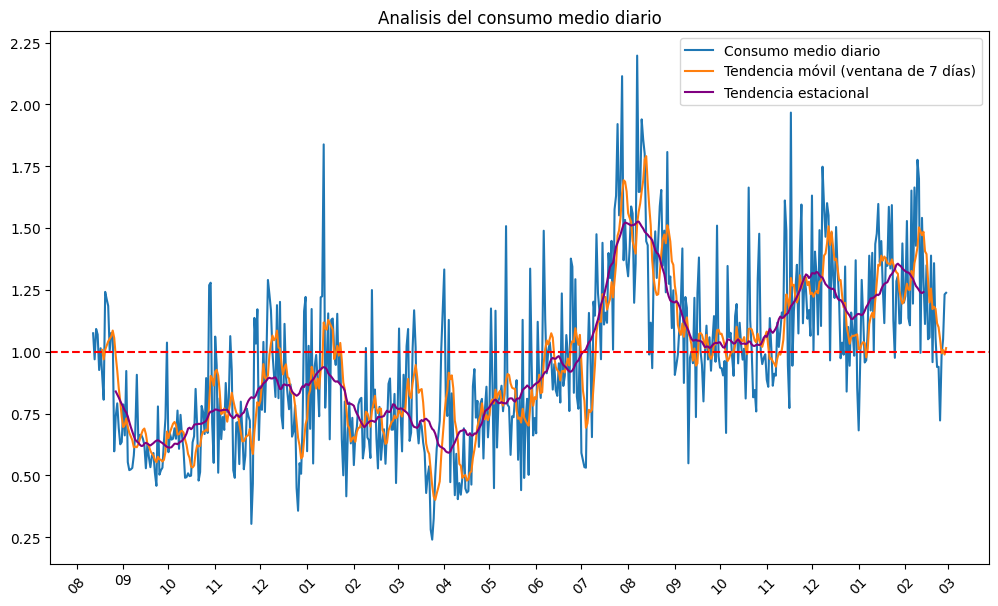

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.tsa.seasonal as seasonal_decompose

ventana = 7
df_media_diaria['tendencia_movil'] = df_media_diaria['consumido'].rolling(window=ventana).mean()

decomposition = seasonal_decompose.seasonal_decompose(df_media_diaria['consumido'], model='additive', period=30)

fig, ax = plt.subplots(figsize=(10, 6))
month_locator = mdates.MonthLocator()
date_formatter = mdates.DateFormatter('%m')
ax.xaxis.set_major_locator(month_locator)
ax.xaxis.set_major_formatter(date_formatter)
plt.xticks(rotation=45)
plt.tight_layout()
plt.plot(df_media_diaria['date'], df_media_diaria['consumido'], label='Consumo medio diario')
plt.plot(df_media_diaria['date'], df_media_diaria['tendencia_movil'], label='Tendencia móvil (ventana de 7 días)')
plt.plot(df_media_diaria['date'], decomposition.trend, color='purple', label='Tendencia estacional')
plt.title('Analisis del consumo medio diario')
plt.legend()
plt.axhline(y=1, color='r', linestyle='--')
plt.show()